# Cross Validation
---
### Author :  Muhammad Ali Saagar

**Python Developer • Data Science • AI/ML Engineer**

#### 🔗 Connect With Me

[![GitHub](https://img.shields.io/badge/GitHub-Profile-181717?style=for-the-badge\&logo=github)](https://github.com/AliMuhammad78)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-0A66C2?style=for-the-badge\&logo=linkedin)](https://www.linkedin.com/in/muhammad-ali-91294a290)
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge\&logo=kaggle)](https://www.kaggle.com/ali98muhammad45)
[![YouTube](https://img.shields.io/badge/YouTube-Channel-FF0000?style=for-the-badge\&logo=youtube)](https://www.youtube.com/@TechyBits20121)
[![Email](https://img.shields.io/badge/Email-Contact-D14836?style=for-the-badge\&logo=gmail)](mailto:alisaagar86@gmail.com)


### Acknowledgement

> Most of the examples in this notebook are based on the excellent tutorials by **Dr. Muhammad Aammar Tufail (Codanics)**. I sincerely thank him for sharing his knowledge and practical examples.

 [![GitHub](https://img.shields.io/badge/GitHub-Profile-181717?style=for-the-badge\&logo=github)](https://github.com/AammarTufail)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-0A66C2?style=for-the-badge\&logo=linkedin)](https://www.linkedin.com/in/dr-muhammad-aammar-tufail-02471213b/)
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge\&logo=kaggle)](https://www.kaggle.com/muhammadaammartufail)
[![YouTube](https://img.shields.io/badge/YouTube-Channel-FF0000?style=for-the-badge\&logo=youtube)](https://www.youtube.com/@codanics)
---


## Definition
**Cross Validation** is a technique used to evaluate the performance of a machine learning model by splitting the dataset into multiple parts and testing the model on different portions of the data.  
It helps in checking how well the model will perform on **unseen data**.

 

## Why Cross Validation is Needed
- Prevents **overfitting**
- Gives a more **reliable estimate** of model performance
- Uses data efficiently (important when dataset is small)
- Ensures model is not dependent on a single train-test split

 

## Basic Idea
Instead of using one train-test split:
- Divide data into multiple parts (folds)
- Train on some parts
- Test on remaining part
- Repeat multiple times
- Take the **average result**

 

## Types of Cross Validation

### 1. Hold-Out Validation
- Split data once (e.g., 80% train, 20% test)
- Simple but less reliable


### 2. K-Fold Cross Validation
- Divide data into **K equal parts (folds)**
- Train on K-1 folds, test on 1 fold
- Repeat K times
- Average the results


### 3. Stratified K-Fold
- Same as K-Fold, but keeps **class distribution balanced**
- Useful for **classification problems**


### 4. Leave-One-Out Cross Validation (LOOCV)
- Each data point is used as a test set once
- Very accurate but computationally expensive


### 5. Repeated K-Fold
- K-Fold applied multiple times with different splits
- Gives more stable results
 

### 6. Time Series Cross Validation
- Used for **time-based data**
- Maintains order (no random shuffling)


## Advantages
- Better performance estimation
- Reduces variance
- Makes model more robust


## Disadvantages
- Computationally expensive
- Slower for large datasets



Cross validation ensures that the model generalizes well by testing it on multiple unseen subsets of data.

---

In [10]:
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
import seaborn as sns 

iris = sns.load_dataset("iris")
X = iris.drop("species" , axis=1)
y= iris['species']

nb = GaussianNB()

scores = cross_val_score(nb  ,X, y, cv=5 , scoring="accuracy")
print("scores = " , scores)
print("mean is " , scores.mean())
print("Standard Deviation is " , scores.std())

scores =  [0.93333333 0.96666667 0.93333333 0.93333333 1.        ]
mean is  0.9533333333333334
Standard Deviation is  0.02666666666666666


# **K-fold Cross Validation vs. train_test split**

In [13]:
# cross validation on tips data
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
import seaborn as sns 

tips = sns.load_dataset("tips")
X = tips[["total_bill" , "size" , "tip"]]
y= tips['sex']

nb = GaussianNB()

scores = cross_val_score(nb  ,X, y, cv=5 , scoring="accuracy")
print("scores = " , scores)
print("mean is " , scores.mean())
print("Standard Deviation is " , scores.std())



scores =  [0.55102041 0.55102041 0.59183673 0.65306122 0.54166667]
mean is  0.5777210884353741
Standard Deviation is  0.04147568336521195


In [15]:
#  using train_test_split 

from sklearn.model_selection import train_test_split 
import numpy as np 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)

 
y_pred = model.predict(X_test)

accuracy = np.mean(y_pred == y_test)
print("Accuracy is " , accuracy)

Accuracy is  0.6530612244897959


> Although train_test_split is giving here more accuracy but cross validation is more robust 

## Plotting CV results 

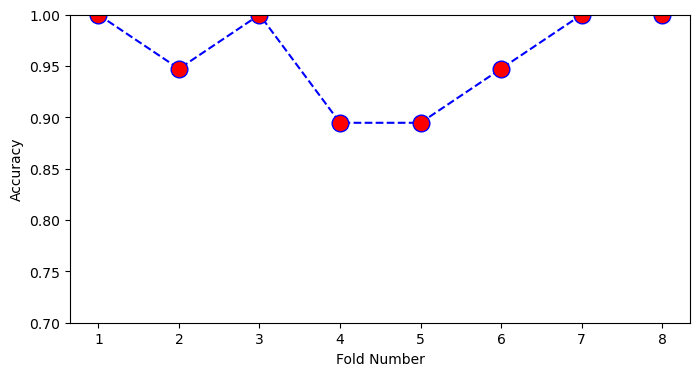

In [17]:
from sklearn.datasets import load_iris 
from sklearn.model_selection import cross_val_score 
from sklearn.tree import DecisionTreeClassifier

import matplotlib.pyplot as plt 
import numpy as np 

iris = load_iris()
X = iris.data
y = iris.target

model = DecisionTreeClassifier()

scores = cross_val_score(model , X , y , cv=8)


plt.figure(figsize=(8,4))
plt.plot(range(1,9) , scores , color = "blue" , linestyle = "dashed" , marker="o" , markerfacecolor='red', markersize=12)
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.ylim(0.7,1)
plt.show()